In [1]:
import os

os.environ["CUDA_VISIBLE_DEVICES"] ='0'

In [121]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split

import torch
from torch import nn

In [122]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
device

'cuda'

In [123]:
X_np, y_np = make_circles(n_samples=2000,
                          factor=0.5,
                          noise=0.08,
                          random_state=42)

In [124]:
print(X_np.shape)
print(y_np.shape)

(2000, 2)
(2000,)


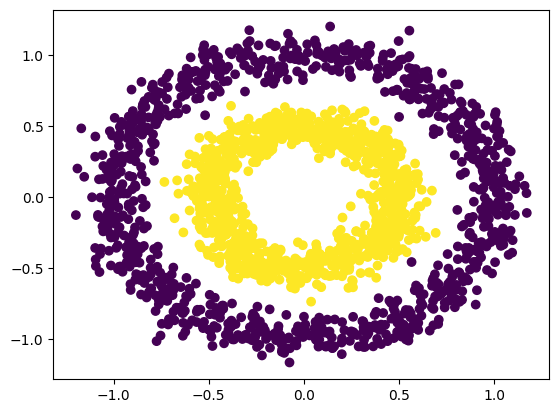

In [125]:
plt.scatter(X_np[:,0], X_np[:,1], c=y_np)
plt.show()

In [126]:
X_train, X_test, y_train, y_test = train_test_split(X_np, y_np, stratify=y_np, random_state=42, test_size=0.2)

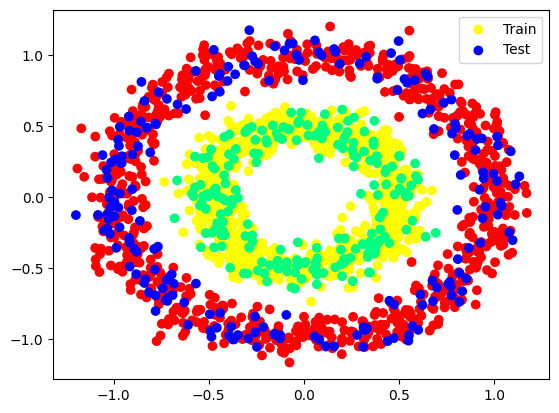

In [127]:
plt.scatter(X_train[:,0], X_train[:,1], c=y_train, cmap='autumn', label='Train') # rojo y amarillo
plt.scatter(X_test[:,0], X_test[:,1], c=y_test, cmap='winter', label='Test') # azul y verde
plt.legend()
plt.show()

In [128]:
class MultiNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.stack = nn.Sequential(
            nn.Linear(2, 32),
            nn.ReLU(),
            nn.Linear(32, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )
        
    def forward(self, x):
        result = self.stack(x)
        return result

In [129]:
model = MultiNet().to(device)
model

MultiNet(
  (stack): Sequential(
    (0): Linear(in_features=2, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=1, bias=True)
  )
)

In [130]:
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

In [131]:
X_train.shape

(1600, 2)

In [132]:
# X_train, X_test, y_train, y_test

X = torch.from_numpy(X_train).float().to(device)
Y = torch.from_numpy(y_train.reshape(-1,1)).float().to(device)

In [133]:
print(X.shape)
print(Y.shape)

torch.Size([1600, 2])
torch.Size([1600, 1])


In [134]:
for epoch in range(500):
    y_pred = model(X)
    loss = criterion(y_pred, Y)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch +1} | Loss: {loss.item():.4f}")

Epoch 100 | Loss: 0.4424
Epoch 200 | Loss: 0.0962
Epoch 300 | Loss: 0.0334
Epoch 400 | Loss: 0.0181
Epoch 500 | Loss: 0.0123


In [135]:
y_pred = model(X)
Y_pred_np = y_pred.detach().cpu().numpy()

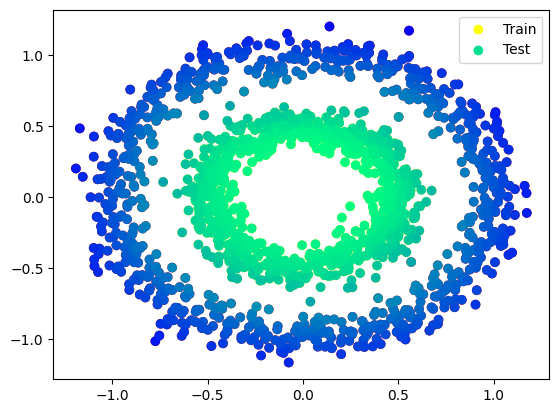

In [136]:
plt.scatter(X_train[:,0], X_train[:,1], c=y_train, cmap='autumn', label='Train') # rojo y amarillo
plt.scatter(X_train[:,0], X_train[:,1], c=Y_pred_np, cmap='winter', label='Test') # azul y verde
plt.legend()
plt.show()

In [137]:
# X_train, X_test, y_train, y_test

In [138]:
X_val_test = torch.from_numpy(X_test).float().to(device)

y_val_pred = model(X_val_test)

In [139]:
Y_val_pred_np = y_val_pred.detach().cpu().numpy()

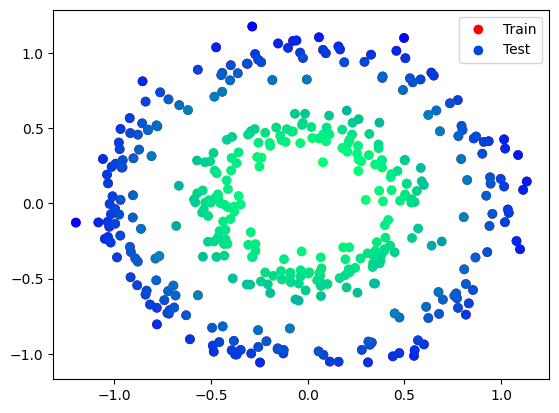

In [140]:
plt.scatter(X_test[:,0], X_test[:,1], c=y_test, cmap='autumn', label='Train') # rojo y amarillo
plt.scatter(X_test[:,0], X_test[:,1], c=Y_val_pred_np, cmap='winter', label='Test') # azul y verde
plt.legend()
plt.show()

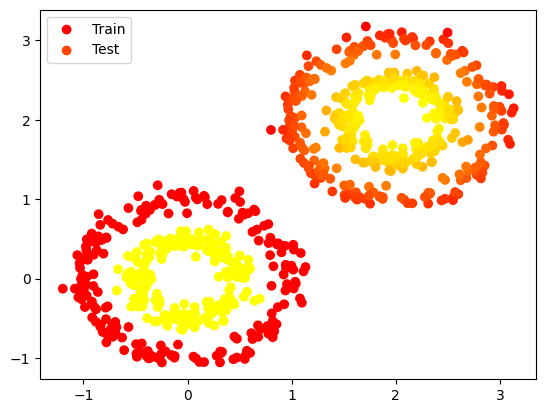

In [141]:
plt.scatter(X_test[:,0], X_test[:,1], c=y_test, cmap='autumn', label='Train') # rojo y amarillo
plt.scatter(X_test[:,0] + 2, X_test[:,1]+2, c=Y_val_pred_np, cmap='autumn', label='Test') # azul y verde
plt.legend()
plt.show()

In [142]:
y_bin = (Y_val_pred_np >= 0.5).astype(np.int32)

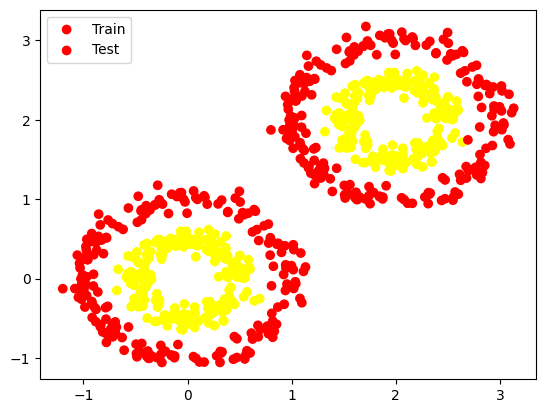

In [143]:
plt.scatter(X_test[:,0], X_test[:,1], c=y_test, cmap='autumn', label='Train') # rojo y amarillo
plt.scatter(X_test[:,0] + 2, X_test[:,1]+2, c=y_bin, cmap='autumn', label='Test') # azul y verde
plt.legend()
plt.show()